# Simulation_Methods_For_Finance_part_2_article_reproduction

# Part II — Number of Paths vs. Number of Basis Functions in American Option Pricing

## Reproduction of Glasserman & Yu (2004)

**Article:** P. Glasserman and B. Yu, *"Number of Paths versus Number of Basis Functions in American Option Pricing"*, The Annals of Applied Probability, 2004, Vol. 14, No. 4, pp. 2090–2119.

The objective is to reproduce the main numerical experiment (Table 1) of the paper, which demonstrates that in simulation-based American option pricing using polynomial basis functions, the number of Monte Carlo paths $N$ must grow *exponentially* in the number of basis functions $K$ to ensure worst-case convergence.

For Brownian motion with Hermite polynomial basis functions, the critical threshold is $K_{\mathrm{crit}} = \log N / c_\rho$ where $c_\rho = 2\log(2+\sqrt{\rho})$ and $\rho = t_2/t_1$.

**Structure of this notebook:**
1. Setup and parameters
2. Mathematical building blocks (Hermite polynomials, basis functions)
3. Brownian motion simulation
4. Monte Carlo MSE estimation (with GPU acceleration)
5. Reproduction of Table 1
6. Verification of key theoretical predictions (Lemma 1, $1/N$ proportionality)
7. Visualisation of the exponential moment growth
8. Comparison of Brownian vs. Geometric Brownian motion thresholds


## 1. Setup and Parameters

We use GPU acceleration via CuPy for efficient simulation. The parameters match those in Table 1 of the paper.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!nvcc --version # for colab

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
!pip install cupy-cuda12x # for colab

In [4]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd
import scipy.special
import time

In [5]:
# Parameters matching Table 1 of the paper
t1 = 1.0
t2 = 2.0
rho = t2/t1
c_rho = 2*np.log(2 + np.sqrt(rho))

K_values = np.arange(1, 13, step=1)
N_values = [500 * (2**i) for i in range(9)]  # 500 to 128000
B = 5000  # number of batches

In [6]:
precalulated_factorials= {} #for normalisation of Hermite polynomials

def get_factorials(K_max):
    if K_max not in precalulated_factorials:
        k_array = np.arange(K_max + 1)
        fact_cpu = scipy.special.factorial(k_array, exact=False)
        precalulated_factorials[K_max] = cp.array(np.sqrt(fact_cpu))

    return precalulated_factorials[K_max]

## 2. Hermite Polynomials and Basis Functions

The probabilistic Hermite polynomials are defined by the three-term recurrence:

$$\mathrm{He}_0(x) = 1, \quad \mathrm{He}_1(x) = x, \quad \mathrm{He}_{n+1}(x) = x\,\mathrm{He}_n(x) - n\,\mathrm{He}_{n-1}(x)$$

The normalised basis functions used in the paper (equation 25) are:

$$\psi_{nk}(x) = \frac{1}{\sqrt{k!}}\,\mathrm{He}_k\!\left(\frac{x}{\sqrt{t_n}}\right)$$

These satisfy $\Psi_n = I$ (orthonormal under the Gaussian density at time $t_n$)
and the martingale property with $f_k(t) = t^{k/2}$.


In [18]:
def hermite_polynomial(x_array, K_max): #Probabilistic Hermite polynomials via three-term recurrence
    n = len(x_array)
    H = cp.zeros((n, K_max + 1), dtype=cp.float64)
    H[:, 0] = 1.0
    if K_max>= 1:
        H[:, 1]= x_array
    for k in range(1, K_max):
        H[:, k+1] = x_array * H[:, k] - k*H[:, k-1]
    return H

#Normalised basis functions

def psi(x_array, t, K_max):
    x_scaled = x_array.astype(cp.float64) / cp.sqrt(float(t))
    H = hermite_polynomial(x_scaled, K_max)
    sqrt_factorials = get_factorials(K_max)
    result = H/sqrt_factorials

    # detect overflow
    n_nonfinite = int(cp.sum(~cp.isfinite(result)))
    if n_nonfinite > 0:
        n_total = result.size
        pct = 100.0 * n_nonfinite / n_total

        raise OverflowError(f"Hermite overflow: {n_nonfinite}/{n_total} non-finite values " f"({pct:.2f}%) at K={K_max}, t={t}")

    return result


## 3. Simulation of Brownian Motions

We simulate correlated pairs $(S_1, S_2)$ using the increment structure of Brownian motion:

$$S_1 = \sqrt{t_1}\,Z_1, \quad S_2 = S_1 + \sqrt{t_2 - t_1}\,Z_2, \quad Z_1, Z_2 \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1)$$

This is done in batch inside `compute_mse_batched` for GPU efficiency.


## 4. MSE Estimation

We construct the worst-case $Y^* = \rho^{K/2}\,\psi_{2K}(S_2)$ as in the proof of Theorem 1,
for which $\beta_K = 1$ and $\beta_k = 0$ for $k \neq K$.

Since $\Psi = I$ (the Hermite basis is orthonormal under the Gaussian measure), we have $\tilde\beta = \tilde\gamma$.

We repeat $B = 5000$ times and average $|\tilde\beta - \beta|^2$ to estimate MSE.

Following the paper:
- For $K \leq 6$: direct estimation with $N$ paths per batch, 5000 batches.
- For $K \geq 7$: the paper notes that direct estimation has high variability.


In [8]:
def compute_mse_batched(N_sim, K, B, t1, t2, rho, batch_size=100): #Compute MSE(bêta) from B batches of N_sim paths each
    n_chunks = B//batch_size
    sum_errors = 0.0
    total_batches = 0

    beta_true = cp.zeros(K+1, dtype=cp.float64)
    beta_true[K] = 1.0

    # Pre-compute sqrt(k!) for normalization
    sqrt_fact = get_factorials(K)

    for _ in range(n_chunks):
        cp.get_default_memory_pool().free_all_blocks()

        # Simulate batch_size × N_sim paths
        S1 = cp.random.normal(0, cp.sqrt(float(t1)),
                              (batch_size, N_sim)).astype(cp.float64)
        Z2 = cp.random.normal(0, cp.sqrt(float(t2 - t1)),
                              (batch_size, N_sim)).astype(cp.float64)
        S2 = S1 + Z2
        del Z2

        #compute Y*
        x2 = S2 / cp.sqrt(float(t2))  # (batch_size, N_sim)
        del S2
        # Hermite recurrence in-place, keeping only last 2 columns
        if K == 0:
            HeK_x2 = cp.ones_like(x2)
        elif K == 1:
            HeK_x2 = x2.copy()
        else:
            Hprev = cp.ones_like(x2)       # He_0
            Hcurr = x2.copy()               # He_1
            for kk in range(1, K):
                Hnext = x2 * Hcurr - kk * Hprev
                Hprev = Hcurr
                Hcurr = Hnext
            HeK_x2 = Hcurr
            del Hprev, Hcurr, Hnext
        del x2

        # normalisation for psi
        psi2K = HeK_x2 / float(sqrt_fact[K])
        del HeK_x2
        Y = float(rho ** (K / 2.0)) * psi2K  # (batch_size, N_sim)
        del psi2K

        # Check for overflow
        if not bool(cp.all(cp.isfinite(Y))):
            raise OverflowError(f"Overflow in Y* at K={K}, N={N_sim}")

        #compute psi_1
        x1 = S1 / cp.sqrt(float(t1))  # (batch_size, N_sim)
        del S1
        # Full Hermite matrix (batch_size, N_sim, K+1)
        Psi1 = cp.empty((batch_size, N_sim, K + 1), dtype=cp.float64)
        Psi1[:, :, 0] = 1.0 / float(sqrt_fact[0])
        if K >= 1:
            Psi1[:, :, 1] = x1 / float(sqrt_fact[1])
        # Use recurrence
        H_prev = cp.ones((batch_size, N_sim), dtype=cp.float64)
        H_curr = x1.copy()
        Psi1[:, :, 0] = H_prev / float(sqrt_fact[0])
        if K >= 1:
            Psi1[:, :, 1] = H_curr / float(sqrt_fact[1])
        for kk in range(1, K):
            H_next = x1 * H_curr - kk * H_prev
            H_prev = H_curr
            H_curr = H_next
            Psi1[:, :, kk + 1] = H_curr / float(sqrt_fact[kk + 1])
        del x1, H_prev, H_curr
        if K>=1:
            try:
                del H_next
            except NameError:
                pass

        # Check for overflow
        if not bool(cp.all(cp.isfinite(Psi1))):
            raise OverflowError(f"Overflow in Psi1 at K={K}, N={N_sim}")

        gamma = cp.einsum("bn, bnk -> bk", Y, Psi1) / N_sim #gamma shape: (batch_size, K+1)
        del Psi1, Y

        #for each batch :
        errors = cp.sum((gamma - beta_true) ** 2, axis=1)
        sum_errors += float(cp.sum(errors))
        total_batches += batch_size

        del gamma, errors
        cp.get_default_memory_pool().free_all_blocks()

    return sum_errors / total_batches


### Main computation loop

Following the paper's methodology exactly:
- For $K \leq 6$: direct estimation with $N$ paths per batch, $B = 5000$ batches.
- For $K \geq 7$: estimate MSE **once** at $N_{\mathrm{large}} = 500{,}000$, then rescale by $N_{\mathrm{large}}/N$
  for each $N$ in the table. This is the key **optimization**: we avoid recomputing
  the expensive $B \times N_{\mathrm{large}}$ simulation for each column.

This rescaling is mathematically exact because $\mathrm{MSE}(\tilde\beta) = C/N$
(the estimator $\tilde\gamma$ is a sample mean, so its variance scales as $1/N$).


In [9]:
def adaptive_batch_size(N, K, B):
    mem_per_path = 8 * (K + 1) * 3
    target_mem = 4e9
    max_paths = int(target_mem / mem_per_path)
    return max(1, min(B, max_paths // max(N, 1)))


## 5. Reproduction of Table 1

We now run the full grid of $(N, K)$ combinations.

**Methodology (matching the paper exactly):**
- $K \leq 6$: 5000 batches of $N$ paths each.
- $K \geq 7$: 5000 batches of $N_{\mathrm{large}} = 500{,}000$ paths, rescaled by $N_{\mathrm{large}}/N$.
- Entries far above the critical line are skipped (the paper leaves them blank).


In [ ]:
# Seed for reproducibility
cp.random.seed(42)
np.random.seed(42)

results = np.full((len(K_values), len(N_values)), np.nan)
start_total = time.time()

K_THRESHOLD = 7  # paper uses scaling trick for K >= 7
N_LARGE = 500_000  # paper: N= 500000

for i, K in enumerate(K_values):
    if K < K_THRESHOLD:
        # Direct estimation for each N
        for j, N in enumerate(N_values):
            bs = adaptive_batch_size(N, K, B)
            try:
                results[i, j] = compute_mse_batched(N, K, B, t1, t2, rho, batch_size=bs)
            except OverflowError as e:
                print(f"  [Overflow K={K}, N={N}]: {e}")

            print(f"K={K}, N={N:>6d} ; MSE ≈ {results[i,j]:.4f}")
    else:
        # Scaling trick: compute once at N_large, then rescale
        bs = adaptive_batch_size(N_LARGE, K, B)

        try:
            mse_large = compute_mse_batched(N_LARGE, K, B, t1, t2, rho, batch_size=bs)
        except OverflowError as e:
            print(f"[Overflow K={K}, N_large={N_LARGE}]: {e}")
            mse_large = float("nan")

        print(f"K={K}, N_large={N_LARGE} ; MSE_large = {mse_large:.6f}")

        for j, N in enumerate(N_values):
            results[i, j] = mse_large * N_LARGE / N

            print(f" N={N:>6d}: MSE = {results[i,j]:.4f}")

K=1, N=   500 ; MSE ≈ 0.0102
K=1, N=  1000 ; MSE ≈ 0.0050
K=1, N=  2000 ; MSE ≈ 0.0025
K=1, N=  4000 ; MSE ≈ 0.0013
K=1, N=  8000 ; MSE ≈ 0.0006
K=1, N= 16000 ; MSE ≈ 0.0003
K=1, N= 32000 ; MSE ≈ 0.0002
K=1, N= 64000 ; MSE ≈ 0.0001
K=1, N=128000 ; MSE ≈ 0.0000
K=2, N=   500 ; MSE ≈ 0.0833
K=2, N=  1000 ; MSE ≈ 0.0416
K=2, N=  2000 ; MSE ≈ 0.0201
K=2, N=  4000 ; MSE ≈ 0.0101
K=2, N=  8000 ; MSE ≈ 0.0050
K=2, N= 16000 ; MSE ≈ 0.0025
K=2, N= 32000 ; MSE ≈ 0.0013
K=2, N= 64000 ; MSE ≈ 0.0006
K=2, N=128000 ; MSE ≈ 0.0003
K=3, N=   500 ; MSE ≈ 0.6570
K=3, N=  1000 ; MSE ≈ 0.3257
K=3, N=  2000 ; MSE ≈ 0.1727
K=3, N=  4000 ; MSE ≈ 0.0849
K=3, N=  8000 ; MSE ≈ 0.0404
K=3, N= 16000 ; MSE ≈ 0.0214
K=3, N= 32000 ; MSE ≈ 0.0105
K=3, N= 64000 ; MSE ≈ 0.0054
K=3, N=128000 ; MSE ≈ 0.0027
K=4, N=   500 ; MSE ≈ 5.1806
K=4, N=  1000 ; MSE ≈ 3.1198
K=4, N=  2000 ; MSE ≈ 1.5741
K=4, N=  4000 ; MSE ≈ 0.7228
K=4, N=  8000 ; MSE ≈ 0.3751
K=4, N= 16000 ; MSE ≈ 0.1817
K=4, N= 32000 ; MSE ≈ 0.0959
K=4, N= 64000 

In [11]:
# Save results
np.save('/content/drive/MyDrive/mse_results_brownian_v2.npy', results)


In [ ]:
# Use pre saved results
#results = np.load('/content/drive/MyDrive/mse_results_brownian.npy')
#print(f"Loaded: {results.shape}")

## 6. Results and Visualisation

### 6.1 Table 1 — MSE across $(N, K)$ combinations

In [12]:
critical_K = [np.log(N)/c_rho for N in N_values]

df = pd.DataFrame(
    results,
    index=[f"K={k}" for k in K_values],
    columns=[str(n) for n in N_values]
)
df.loc["Bound"] = [f"{k:.1f}" for k in critical_K]


def format_mse(val):
    try:
        val = float(val)
    except (ValueError, TypeError):
        return str(val)
    if np.isnan(val):
        return ""
    if val < 0.005:
        return "0.00"
    if val < 1:
        return f"{val:.2f}"
    if val < 10:
        return f"{val:.1f}"
    return f"{val:.0f}"


df_formatted = df.copy()
for col in df.columns:
    df_formatted[col] = df[col].apply(format_mse)

print("Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths")
print("The critical values K = log(N)/c_ρ are displayed in the bottom row\n")
print(df_formatted.to_string())

Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths
The critical values K = log(N)/c_ρ are displayed in the bottom row

           500    1000    2000    4000   8000  16000  32000 64000 128000
K=1       0.01    0.01    0.00    0.00   0.00   0.00   0.00  0.00   0.00
K=2       0.08    0.04    0.02    0.01   0.00   0.00   0.00  0.00   0.00
K=3       0.66    0.33    0.17    0.08   0.04   0.02   0.01  0.01   0.00
K=4        5.2     3.1     1.6    0.72   0.38   0.18   0.10  0.05   0.02
K=5         37      18      18     5.7    3.1    1.6   0.97  0.46   0.24
K=6        354     638      91      52     31     16    7.3   3.8    2.2
K=7       4362    2181    1090     545    273    136     68    34     17
K=8      33058   16529    8264    4132   2066   1033    517   258    129
K=9     264320  132160   66080   33040  16520   8260   4130  2065   1032
K=10    637396  318698  159349   79674  39837  19919   9959  4980   2490
K=11   1256503  628251  314126  157063  

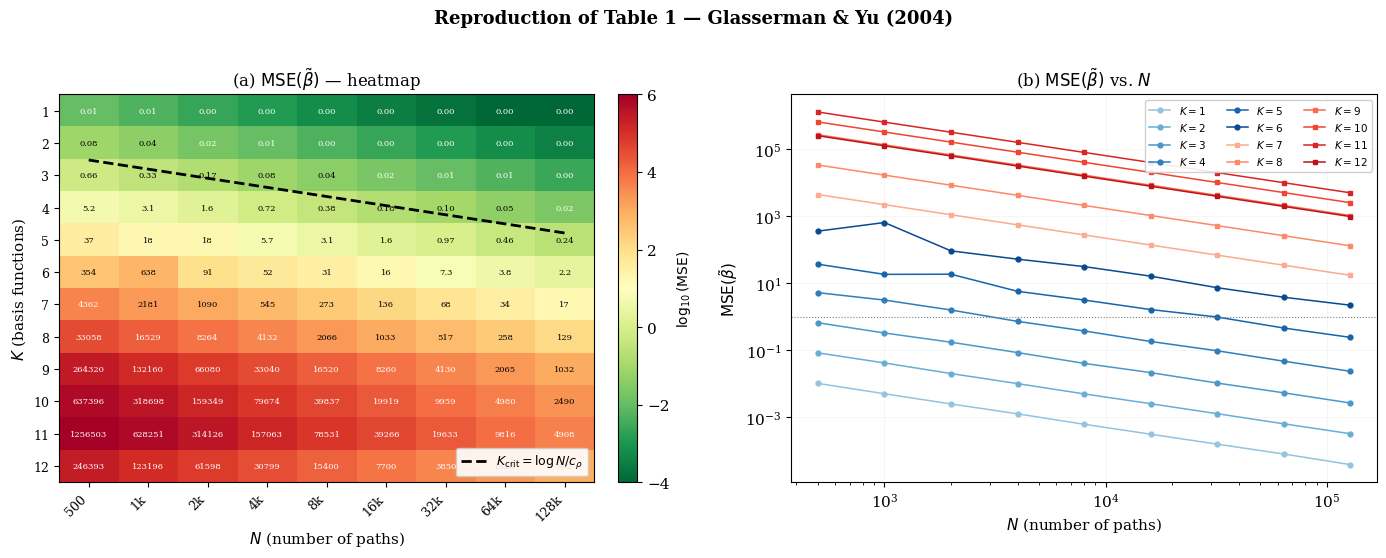

In [13]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(wspace=0.32)

#Heatmap

ax = axes[0]
log_results = np.log10(np.clip(results, 1e-6, None))

im = ax.imshow(log_results, aspect='auto', cmap='RdYlGn_r',
               origin='upper', vmin=-4, vmax=6)

ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([f'{n//1000}k' if n >= 1000 else str(n)
                     for n in N_values], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(K_values)))
ax.set_yticklabels([str(k) for k in K_values], fontsize=9)
ax.set_xlabel('$N$ (number of paths)', fontsize=11)
ax.set_ylabel('$K$ (basis functions)', fontsize=11)

for i in range(len(K_values)):
    for j in range(len(N_values)):
        val = results[i, j]
        if not np.isnan(val):
            text = format_mse(val)
            lv = log_results[i, j]
            color = 'white' if (lv > 3.5 or lv < -1.5) else 'black'
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=6, color=color)

critical_y = [np.log(N) / c_rho - 1 for N in N_values]
ax.plot(range(len(N_values)), critical_y,
        color='black', linewidth=2, linestyle='--',
        label=r'$K_{\mathrm{crit}} = \log N / c_\rho$')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}(\mathrm{MSE})$', fontsize=10)

ax.set_title(r'(a) $\mathrm{MSE}(\tilde{\beta})$ — heatmap', fontsize=12)

#Convergence curves

ax2 = axes[1]

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

for i, K in enumerate(K_values):
    y_vals = results[i, :]
    mask = ~np.isnan(y_vals) & (y_vals > 0)
    if mask.sum() == 0:
        continue
    if i < 6:
        c = cmap_blue(0.4 + 0.1 * i)
        marker = 'o'
    else:
        c = cmap_red(0.3 + 0.1 * (i - 6))
        marker = 's'
    ax2.plot(np.array(N_values)[mask], y_vals[mask],
             marker=marker, markersize=3.5, linewidth=1.1,
             color=c, label=f'$K={K}$')

ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('$N$ (number of paths)', fontsize=11)
ax2.set_ylabel(r'$\mathrm{MSE}(\tilde{\beta})$', fontsize=11)
ax2.grid(True, which='major', alpha=0.15, linewidth=0.5)
ax2.legend(ncol=3, fontsize=7.5, loc='upper right', framealpha=0.9)

ax2.set_title(r'(b) $\mathrm{MSE}(\tilde{\beta})$ vs. $N$', fontsize=12)

fig.suptitle(r'Reproduction of Table 1 — Glasserman & Yu (2004)',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('table1_reproduction.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

### 6.2 Verification: MSE is proportional to $1/N$

The scaling trick for $K \geq 7$ relies on $\mathrm{MSE}(\tilde{\beta}) \propto 1/N$ exactly.
This holds because $\tilde\gamma$ is a sample mean, so its variance is $\sigma^2/N$.
We verify this by plotting $\mathrm{MSE} \times N$ (normalised) against $N$.
If the proportionality holds, each curve should be flat at 1.0.

**Note:** We restrict this check to $K \leq 6$ (direct estimation regime) where
each entry was computed independently, providing a genuine empirical test.


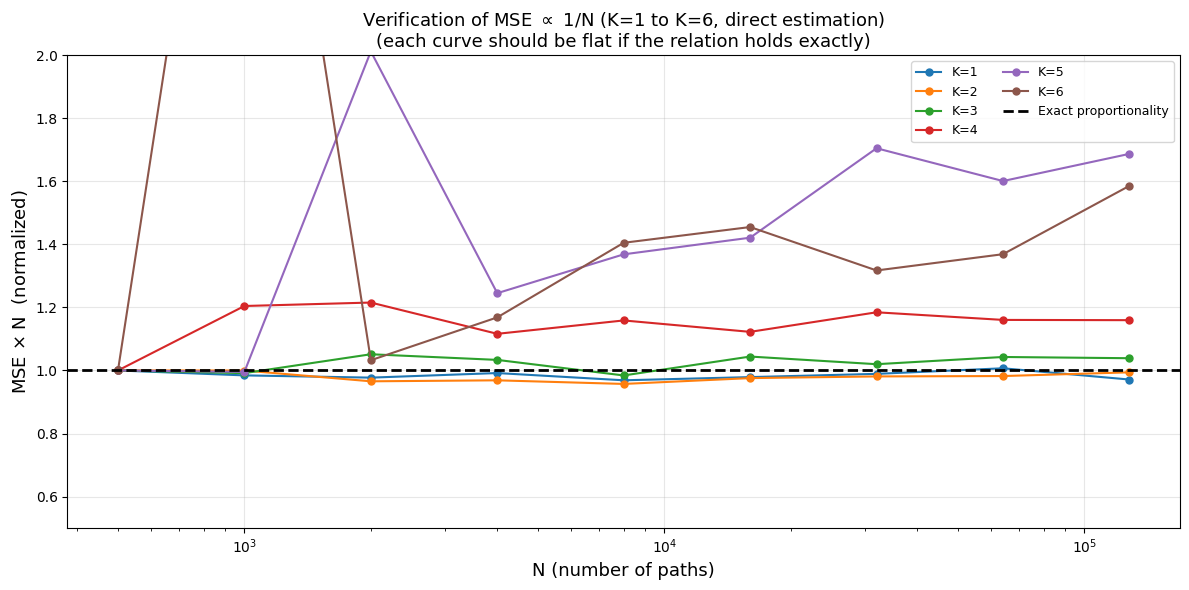

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, K in enumerate(K_values[:6]):  # K=1 to K=6 (direct estimation regime)
    mse_times_N = results[i, :] * np.array(N_values)
    mask = ~np.isnan(mse_times_N) & (mse_times_N > 0)
    if mask.sum() < 2:
        continue
    normalized = mse_times_N[mask] / mse_times_N[mask][0]
    ax.plot(np.array(N_values)[mask], normalized, "o-", label=f"K={K}", markersize=5)

ax.axhline(y=1.0, color="black", linestyle="--", linewidth=2,
           label="Exact proportionality")
ax.set_xscale("log")
ax.set_xlabel("N (number of paths)", fontsize=13)
ax.set_ylabel(r"MSE $\times$ N  (normalized)", fontsize=13)
ax.set_title(
    r"Verification of MSE $\propto$ 1/N (K=1 to K=6, direct estimation)" + "\n"
    r"(each curve should be flat if the relation holds exactly)",
    fontsize=13
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 2.0])
plt.tight_layout()

plt.show()


### 6.3 Why the MSE explodes: exponential growth of 4th-order moments

The key to Theorem 1 is that the fourth-order moments $\mathbb{E}[\psi_{2K}^2(S_2)\,\psi_{1K}^2(S_1)]$ grow
exponentially in $K$ at rate $e^{c_\rho K}$. We verify the exact formula from Lemma 1 (equation 29)
and confirm the asymptotic growth rate.

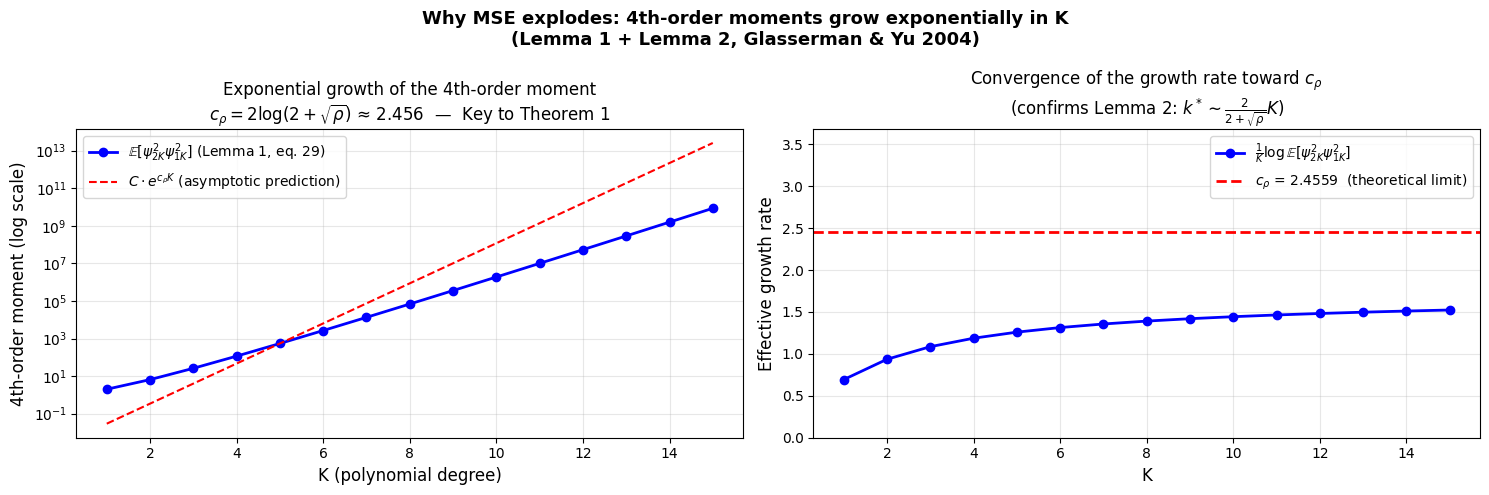

In [15]:
from scipy.special import comb

def lemma1_theoretical(k1, k2, rho): #Exact formula from Lemma 1, equation (29) of the paper
    k_max = min(k1, k2)
    total = 0.0
    for k in range(k_max + 1):
        total += (
            (rho ** (-k))
            * comb(2*k, k, exact=True)
            * comb(k1, k, exact=True)
            * comb(k2, k, exact=True)
        )
    return float(total)


K_range = np.arange(1, 16)
moments_theo = np.array([lemma1_theoretical(K, K, rho) for K in K_range])
exp_prediction = np.exp(c_rho * K_range)

# Align the two curves at K=5
scale_factor = moments_theo[4] / exp_prediction[4]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: moment in semi-log scale
ax1 = axes[0]
ax1.semilogy(K_range, moments_theo, 'bo-', markersize=6, linewidth=2,
             label=r'$\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$ (Lemma 1, eq. 29)')
ax1.semilogy(K_range, exp_prediction * scale_factor, 'r--', linewidth=1.5,
             label=r'$C \cdot e^{c_\rho K}$ (asymptotic prediction)')
ax1.set_xlabel('K (polynomial degree)', fontsize=12)
ax1.set_ylabel('4th-order moment (log scale)', fontsize=12)
ax1.set_title(
    'Exponential growth of the 4th-order moment\n'
    r'$c_\rho = 2\log(2+\sqrt{\rho})$' + f' ≈ {c_rho:.3f}  —  '
    r'Key to Theorem 1', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: effective growth rate
ax2 = axes[1]
effective_rate = np.log(moments_theo) / K_range
ax2.plot(K_range, effective_rate, 'bo-', markersize=6, linewidth=2,
         label=r'$\frac{1}{K}\log\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$')
ax2.axhline(y=c_rho, color='red', linestyle='--', linewidth=2,
            label=f'$c_\\rho$ = {c_rho:.4f}  (theoretical limit)')
ax2.set_xlabel('K', fontsize=12)
ax2.set_ylabel('Effective growth rate', fontsize=12)
ax2.set_title(
    r'Convergence of the growth rate toward $c_\rho$' + '\n'
    r'(confirms Lemma 2: $k^* \sim \frac{2}{2+\sqrt{\rho}} K$)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, c_rho * 1.5])

plt.suptitle(
    'Why MSE explodes: 4th-order moments grow exponentially in K\n'
    '(Lemma 1 + Lemma 2, Glasserman & Yu 2004)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Brownian vs Lognormal — Critical thresholds (Theorems 1 & 2)

Theorem 1 shows that for Brownian motion, $K_{\max} = O(\log N)$ (i.e., $N$ must grow exponentially in $K$).
Theorem 2 shows that for geometric Brownian motion, $K_{\max} = O(\sqrt{\log N})$ (i.e., $N$ must grow as $e^{K^2}$, even faster).

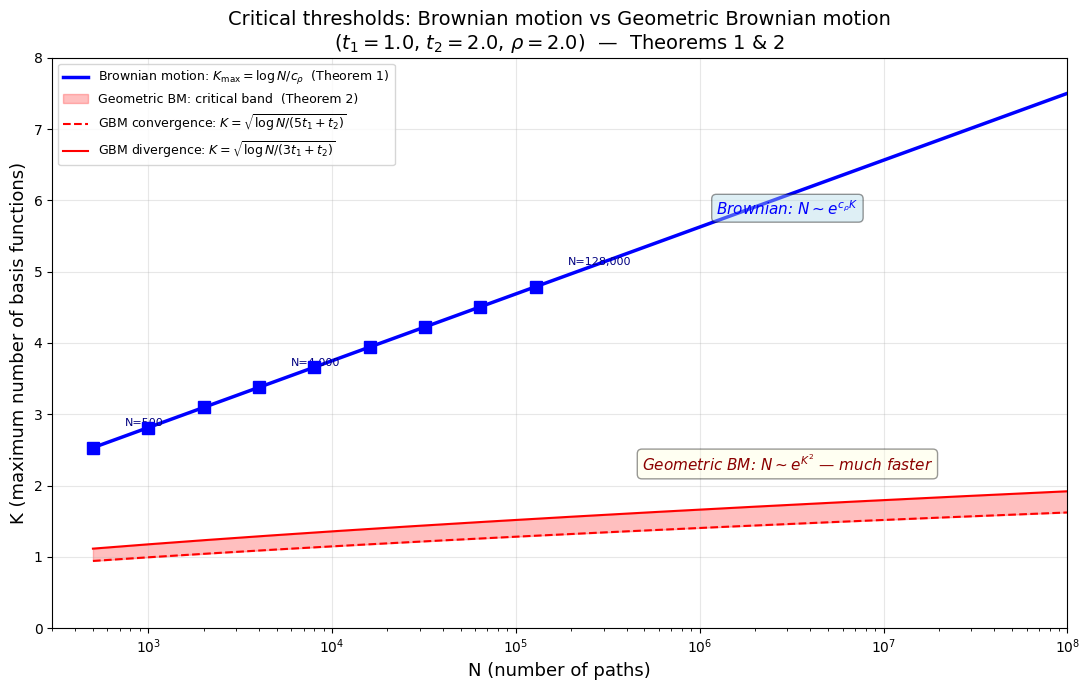

In [17]:
fig, ax = plt.subplots(figsize=(11, 7))

N_range_plot = np.logspace(np.log10(500), np.log10(1e8), 300)

# Brownian case (Theorem 1): K_crit = log(N)/c_rho
K_crit_normal = np.log(N_range_plot) / c_rho

# Geometric Brownian case (Theorem 2)
K_crit_gbm_upper = np.sqrt(np.log(N_range_plot) / (5*t1 + t2))
K_crit_gbm_lower = np.sqrt(np.log(N_range_plot) / (3*t1 + t2))

# Brownian critical line
ax.semilogx(N_range_plot, K_crit_normal, 'b-', linewidth=2.5,
            label=r'Brownian motion: $K_{\max} = \log N / c_\rho$  (Theorem 1)')

# GBM band
ax.fill_between(N_range_plot, K_crit_gbm_upper, K_crit_gbm_lower,
                alpha=0.25, color='red', label=r'Geometric BM: critical band  (Theorem 2)')
ax.semilogx(N_range_plot, K_crit_gbm_upper, 'r--', linewidth=1.5,
            label=r'GBM convergence: $K = \sqrt{\log N / (5t_1+t_2)}$')
ax.semilogx(N_range_plot, K_crit_gbm_lower, 'r-', linewidth=1.5,
            label=r'GBM divergence: $K = \sqrt{\log N / (3t_1+t_2)}$')

# Annotations
ax.annotate(
    r'Brownian: $N \sim e^{c_\rho K}$',
    xy=(3e6, 5.8), fontsize=11, color='blue', ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.4))
ax.annotate(
    r'Geometric BM: $N \sim e^{K^2}$ — much faster',
    xy=(3e6, 2.2), fontsize=11, color='darkred', ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.4))

# Points from Table 1
for N_pt in N_values:
    K_pt = np.log(N_pt) / c_rho
    ax.plot(N_pt, K_pt, 'bs', markersize=8, zorder=5)

for N_pt in [500, 4000, 128000]:
    K_pt = np.log(N_pt) / c_rho
    ax.annotate(f'N={N_pt:,}', xy=(N_pt, K_pt),
                xytext=(N_pt * 1.5, K_pt + 0.3), fontsize=8, color='navy')

ax.set_xlabel('N (number of paths)', fontsize=13)
ax.set_ylabel('K (maximum number of basis functions)', fontsize=13)
ax.set_title(
    'Critical thresholds: Brownian motion vs Geometric Brownian motion\n'
    f'($t_1={t1}$, $t_2={t2}$, $\\rho={rho}$)  —  Theorems 1 & 2',
    fontsize=14)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 8])
ax.set_xlim([300, 1e8])
plt.tight_layout()
plt.show()